# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src_train.touch_dataset import TouchPairDataset

EPIC_KITCHEN_ANNOTATION_DIR = PROJECT_ROOT / "data" / "epic_kitchen" / "annotations"

/home/doterog/repos/uva/research/FOMO/touch_from_segmentation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Viz Functions

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_tensor_row(pixel_values, prompt_pixel_values, prompt_masks, labels,
                    ctx_mask_rgb=None, qry_mask_rgb=None, figsize_per_plot=(4, 4),
                    save_path: str = None):

    def to_numpy(t: torch.Tensor) -> np.ndarray:
        arr = t.detach().cpu().float().numpy()
        if arr.ndim == 3:
            if arr.shape[0] in (1, 3, 4):
                arr = arr.transpose(1, 2, 0)
            if arr.shape[-1] == 1:
                arr = arr.squeeze(-1)
        lo, hi = arr.min(), arr.max()
        if hi > lo:
            arr = (arr - lo) / (hi - lo)
        return arr

    def build_multilabel_overlay(mask_np, alpha=0.55):
        h, w = mask_np.shape[:2]
        rgba = np.zeros((h, w, 4), dtype=np.float32)

        if mask_np.ndim == 2:
            fg = mask_np > 0.05
            rgba[fg] = [1.0, 0.0, 0.0, alpha]
            return rgba

        mask_u8 = (mask_np * 255).astype(np.uint8).reshape(-1, 3)
        unique_colors = np.unique(mask_u8, axis=0)
        unique_colors = unique_colors[unique_colors.max(axis=1) >= 15]

        if len(unique_colors) > 20:
            intensity = mask_np.mean(axis=-1) if mask_np.ndim == 3 else mask_np
            rgba[..., 0] = 1.0
            rgba[..., 1] = 0.4
            rgba[..., 2] = 0.0
            rgba[..., 3] = intensity * alpha
            return rgba

        palette = plt.cm.tab10.colors
        for i, uc in enumerate(unique_colors):
            if uc.max() < 15:
                continue
            lo, hi = uc.astype(int) - 10, uc.astype(int) + 10
            match = np.all((mask_u8 >= lo) & (mask_u8 <= hi), axis=1).reshape(h, w)
            rgba[match, :3] = palette[i % len(palette)]
            rgba[match, 3] = alpha

        return rgba

    def overlay(ax, base, mask, title, alpha=0.55):
        base_np = to_numpy(base)
        mask_np = to_numpy(mask)
        ax.imshow(base_np, cmap="gray" if base_np.ndim == 2 else None)
        ax.imshow(build_multilabel_overlay(mask_np, alpha=alpha))
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    # Fixed: single comprehension, checking the actual image object
    extra = [(img, title) for title, img in
             [("ctx_mask_rgb", ctx_mask_rgb), ("qry_mask_rgb", qry_mask_rgb)]
             if img is not None]

    n_cols = 2 + len(extra)
    fig, axes = plt.subplots(1, n_cols, figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1]))

    overlay(axes[0], base=prompt_pixel_values, mask=prompt_masks,
            title="prompt_pixels + prompt_mask")
    overlay(axes[1], base=pixel_values, mask=labels,
            title="pixel_values + labels")

    for ax, (img, title) in zip(axes[2:], extra):
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()

# Load model and dataset

In [2]:
from transformers import SegGptImageProcessor

processor = SegGptImageProcessor.from_pretrained("BAAI/seggpt-vit-large")

dataset = TouchPairDataset(EPIC_KITCHEN_ANNOTATION_DIR / "train.json", processor, augment=False)

  Loaded 2,880 samples from /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/epic_kitchen/annotations/train.json
  Context index loaded: 182 groups


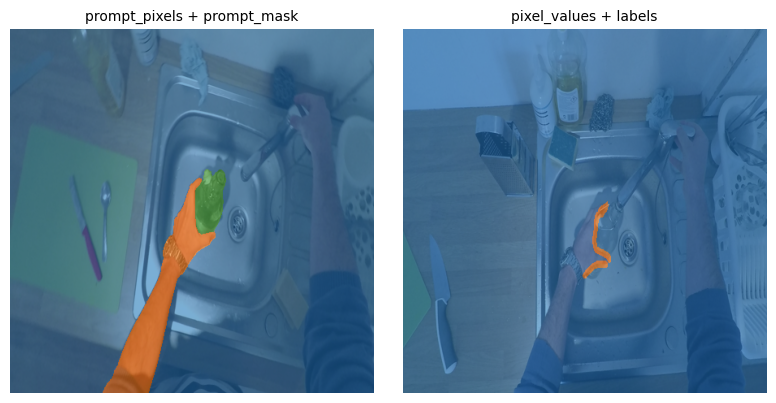

In [6]:
out_dict = dataset[3]

plot_tensor_row(**out_dict)

In [3]:
# sort by number of samples per context
sorted_contexts = sorted(
    dataset._ctx_index.items(),
    key=lambda item: len(item[1]),
    reverse=True
)
print([(ctx, len(samples)) for ctx, samples in sorted_contexts])

[('pan', 204), ('knife', 194), ('spatula', 125), ('spoon', 98), ('plate', 81), ('drawer', 80), ('cupboard', 77), ('lid', 71), ('container', 63), ('plastic spatula', 60), ('chopping board', 58), ('wooden spoon', 58), ('tap', 57), ('cloth', 51), ('fridge', 47), ('cup', 43), ('kettle', 43), ('onion', 40), ('scissors', 38), ('saucepan', 38), ('tong', 35), ('sponge', 34), ('glass', 29), ('bottle', 28), ('bag', 28), ('cereal box', 28), ('frying pan', 27), ('pot', 26), ('bin/garbage can/recycling bin', 25), ('broccoli', 25), ('colander', 23), ('pasta fork', 23), ('oil bottle', 22), ('bread', 22), ('cutlery', 22), ('mesh', 21), ('pasta', 21), ('aubergine', 21), ('salt', 20), ('cereal bag', 20), ('hob/cooktop/stovetop', 20), ('milk bottle', 19), ('mug', 18), ('coffee machine', 18), ('sausage box', 17), ('soy milk', 16), ('salt container', 16), ('carrot', 16), ('mozzarella package', 16), ('bread bag', 15), ('tongs', 14), ('sauce bottle', 14), ('courgette', 14), ('sieve', 13), ('jam jar', 13), ('

# Overfit to Single Sample

Loading weights: 100%|██████████| 354/354 [00:00<00:00, 1378.00it/s]


step    0 | loss 4.69931
step   25 | loss 1.93729
step   50 | loss 0.42326
step   75 | loss 0.09782
step  100 | loss 0.03927
step  125 | loss 0.02378
step  150 | loss 0.04398
step  175 | loss 0.01539
step  200 | loss 0.01699
step  225 | loss 0.02020
step  250 | loss 0.03643
step  275 | loss 0.01434
step  299 | loss 0.01396


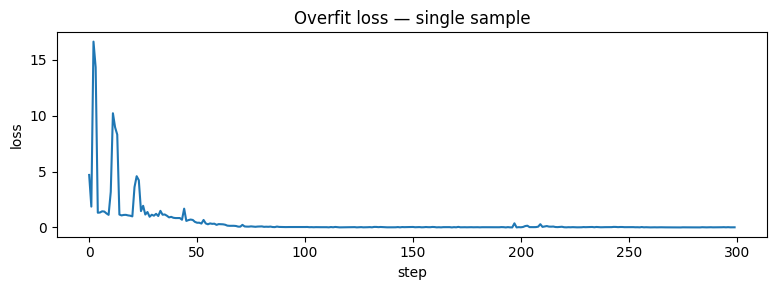

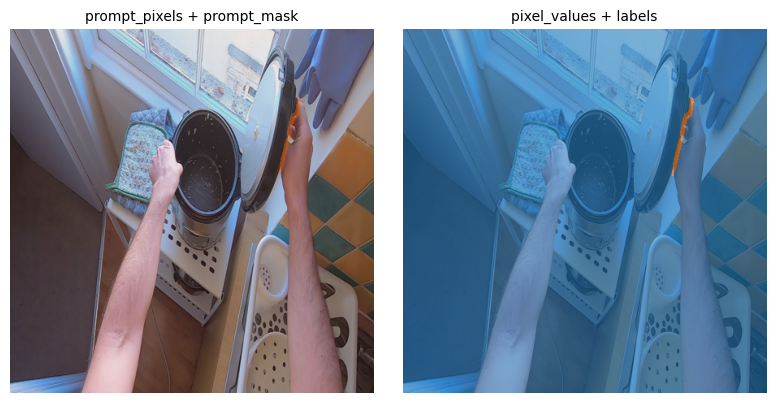

In [10]:
import torch
from src_train.lit_module import SegGPTTouchModule

# ── 1. Grab a single sample and fake a batch of size 1 ──────────────────────
sample = dataset[5]

batch = {
    k: v.unsqueeze(0).cuda()
    for k, v in sample.items()
    if isinstance(v, torch.Tensor)
}

# ── 2. Instantiate model + processor ────────────────────────────────────────
module = SegGPTTouchModule(freeze_encoder=True).cuda()
module.train()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, module.model.parameters()),
    lr=1e-2,
)

# ── 3. Overfit loop ──────────────────────────────────────────────────────────
n_steps = 300
log_every = 25

losses = []
for step in range(n_steps):
    optimizer.zero_grad()

    B = batch["pixel_values"].shape[0]
    device = batch["pixel_values"].device
    bool_masked_pos = module._train_masked_pos(B, device)

    outputs = module.model(
        pixel_values=batch["pixel_values"],
        prompt_pixel_values=batch["prompt_pixel_values"],
        prompt_masks=batch["prompt_masks"],
        bool_masked_pos=bool_masked_pos,
        embedding_type="instance",
    )

    loss = module._focal_touch_loss(
        outputs.pred_masks,
        batch["prompt_masks"],
        batch["labels"],
        bool_masked_pos,
    )

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % log_every == 0 or step == n_steps - 1:
        print(f"step {step:>4d} | loss {loss.item():.5f}")

# ── 4. Plot loss curve ───────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Overfit loss — single sample")
plt.xlabel("step"); plt.ylabel("loss")
plt.tight_layout(); plt.show()

# ── 5. Visualise final prediction vs GT ─────────────────────────────────────
module.eval()
with torch.no_grad():
    bool_masked_pos = module._val_masked_pos(1, device)
    outputs = module.model(
        pixel_values=batch["pixel_values"],
        prompt_pixel_values=batch["prompt_pixel_values"],
        prompt_masks=batch["prompt_masks"],
        labels=batch["labels"],
        bool_masked_pos=bool_masked_pos,
        embedding_type="instance",
    )

pred = outputs.pred_masks          # (1, 3, 2H, W)
H = pred.shape[2] // 2
pred_target = pred[0, :, H:, :]   # (3, H, W)  — target half only
gt = batch["labels"][0]            # (3, H, W)

plot_tensor_row(
    pixel_values=batch["pixel_values"][0].cpu(),
    prompt_pixel_values=batch["pixel_values"][0].cpu(),
    prompt_masks=pred_target.detach().cpu(),
    labels=gt.detach().cpu(),
)

# Fit on a single ctx type

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from src_train.lit_module import SegGPTTouchModule

# ── 1. Setup ────────────────────────────────────────────────────────────────
category = "pan"
indices = dataset._ctx_index[category]
print(f"Using {len(indices)} samples for category '{category}'")

subset = Subset(dataset, indices)
loader = DataLoader(subset, batch_size=16, shuffle=True, num_workers=0)

module = SegGPTTouchModule(freeze_encoder=True).cuda()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, module.model.parameters()), lr=1e-4
)

def to_cuda(batch):
    return {k: v.cuda() for k, v in batch.items() if isinstance(v, torch.Tensor)}

def forward(batch, masked_pos_fn):
    B, device = batch["pixel_values"].shape[0], batch["pixel_values"].device
    bool_masked_pos = masked_pos_fn(B, device)
    outputs = module.model(
        pixel_values=batch["pixel_values"],
        prompt_pixel_values=batch["prompt_pixel_values"],
        prompt_masks=batch["prompt_masks"],
        labels=batch["labels"],
        bool_masked_pos=bool_masked_pos,
        embedding_type="instance",
    )
    return outputs, bool_masked_pos

# ── 2. Overfit loop ─────────────────────────────────────────────────────────
n_steps, log_every = 300, 5
losses = []
module.train()

loader_iter = iter(loader)
for step in range(n_steps):
    try:
        batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        batch = next(loader_iter)
    batch = to_cuda(batch)

    optimizer.zero_grad()
    outputs, bool_masked_pos = forward(batch, module._train_masked_pos)
    loss = module._focal_touch_loss(
        outputs.pred_masks, batch["prompt_masks"], batch["labels"], bool_masked_pos
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(module.model.parameters(), max_norm=1.0)
    optimizer.step()
    losses.append(loss.item())

    if step % log_every == 0 or step == n_steps - 1:
        print(f"step {step:>4d} | loss {loss.item():.5f}")

# ── 3. Loss curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title(f"Overfit loss — category '{category}'")
plt.xlabel("step"); plt.ylabel("loss")
plt.tight_layout(); plt.show()

# ── 4. Visualise predictions ────────────────────────────────────────────────
module.eval()
vis_loader = DataLoader(Subset(dataset, indices[:4]), batch_size=1)

with torch.no_grad():
    for batch in vis_loader:
        batch = to_cuda(batch)
        outputs, _ = forward(batch, module._val_masked_pos)
        H = outputs.pred_masks.shape[2] // 2
        plot_tensor_row(
            pixel_values=batch["pixel_values"][0].cpu(),
            prompt_pixel_values=batch["prompt_pixel_values"][0].cpu(),
            prompt_masks=outputs.pred_masks[0, :, H:, :].cpu(),
            labels=batch["labels"][0].cpu(),
        )

Using 204 samples for category 'pan'


Loading weights: 100%|██████████| 354/354 [00:00<00:00, 1177.74it/s]
